# 05 — K-Means Customer Clustering

*Executed analytical companion to the validated production pipeline.*

## Objective

Explain feature preparation, K=2–10 evaluation, five-seed stability, the K=2 mathematical benchmark, and the operational K=4 customer profiles using existing clustering outputs.

## Business Questions

- How were skewed RFM features made suitable for K-Means?
- Which K is mathematically strongest, and why is a different K used operationally?
- Are the candidate solutions stable and free of tiny clusters?
- What do the final four descriptive profiles suggest for targeting?

## Inputs

- `reports/clustering/k_evaluation.csv`
- `reports/clustering/cluster_profiles.csv`
- `reports/clustering/rfm_cluster_comparison.csv`
- `reports/clustering/clustering_summary.json`
- Existing charts under `images/clustering/`
- Reusable constants from `retail_analytics.clustering`

## Methodology

Read evaluated and exported model outputs. The notebook does not refit K-Means. Production preprocessing applies `log1p` to recency, frequency, and monetary value, then standardises the transformed features. PCA is used only for two-dimensional visualisation.

## Code

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "src" / "retail_analytics").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

def load_json(relative_path):
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

from retail_analytics.clustering import (
    CLUSTERING_FEATURES,
    FINAL_CLUSTER_LABELS,
    KMEANS_N_INIT,
    RANDOM_STATE,
    STABILITY_SEEDS,
)

evaluation = pd.read_csv(PROJECT_ROOT / "reports" / "clustering" / "k_evaluation.csv")
profiles = pd.read_csv(PROJECT_ROOT / "reports" / "clustering" / "cluster_profiles.csv")
summary = load_json("reports/clustering/clustering_summary.json")
print("Features:", CLUSTERING_FEATURES)
print("Seeds:", STABILITY_SEEDS)
print(f"Final fit contract: random_state={RANDOM_STATE}, n_init={KMEANS_N_INIT}")

Project root: C:\Projects\Retail-Customer-Intelligence-Analytics
Python: 3.12.7


Features: ['recency_days', 'frequency_orders', 'monetary_value_gbp']
Seeds: (42, 7, 21, 84, 123)
Final fit contract: random_state=42, n_init=20


In [2]:
evaluation_view = evaluation[
    ["k", "inertia", "silhouette_score", "calinski_harabasz_score", "davies_bouldin_score",
     "minimum_cluster_share_pct", "mean_pairwise_ari", "minimum_pairwise_ari",
     "selection_rank_sum", "metric_optimal", "operational_chosen"]
].copy()
for column in ["silhouette_score", "davies_bouldin_score", "mean_pairwise_ari", "minimum_pairwise_ari"]:
    evaluation_view[column] = evaluation_view[column].map(lambda value: f"{value:.3f}")
evaluation_view["inertia"] = evaluation_view["inertia"].map(lambda value: f"{value:,.1f}")
evaluation_view["calinski_harabasz_score"] = evaluation_view["calinski_harabasz_score"].map(lambda value: f"{value:,.1f}")
evaluation_view["minimum_cluster_share_pct"] = evaluation_view["minimum_cluster_share_pct"].map(lambda value: f"{value:.2f}%")
display(evaluation_view)

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_share_pct,mean_pairwise_ari,minimum_pairwise_ari,selection_rank_sum,metric_optimal,operational_chosen
0,2,"8,577.1",0.438,"6,204.7",0.872,39.95%,0.996,0.992,6.0,True,False
1,3,"6,336.7",0.348,"5,237.2",1.036,21.47%,0.999,0.999,15.0,False,False
2,4,"4,895.4",0.366,"5,095.0",0.929,20.48%,0.997,0.994,9.0,False,True
3,5,"4,069.3",0.346,"4,894.4",0.951,8.17%,0.981,0.962,15.0,False,False
4,6,"3,535.2",0.334,"4,683.7",0.961,7.96%,0.920,0.876,23.0,False,False
5,7,"3,170.8",0.303,"4,463.3",0.985,5.67%,0.965,0.934,24.0,False,False
6,8,"2,882.2",0.296,"4,292.0",0.992,6.07%,0.967,0.942,26.0,False,False
7,9,"2,640.4",0.288,"4,166.0",1.024,4.51%,0.940,0.890,33.0,False,False
8,10,"2,448.2",0.290,"4,044.3",1.015,3.78%,0.977,0.955,29.0,False,False


## Results

K=2 is preserved as the **metric benchmark** because it has the best composite rank sum. K=4 is the **operational solution** because it retains acceptable separation, excellent stability, a 20.48% minimum cluster share, no tiny clusters, and materially more targeting resolution. This is a documented business choice, not a claim that K=4 is mathematically superior to K=2.

In [3]:
comparison = pd.DataFrame([
    {
        "Decision role": "Metric benchmark",
        "K": summary["metric_optimal_k"],
        "Composite rank": summary["metric_optimal_metrics"]["selection_rank_sum"],
        "Silhouette": summary["metric_optimal_metrics"]["silhouette_score"],
        "Davies-Bouldin": summary["metric_optimal_metrics"]["davies_bouldin_score"],
        "Mean ARI": summary["metric_optimal_metrics"]["mean_pairwise_ari"],
        "Minimum cluster share": f"{summary['metric_optimal_metrics']['minimum_cluster_share_pct']:.2f}%",
    },
    {
        "Decision role": "Operational solution",
        "K": summary["operational_chosen_k"],
        "Composite rank": summary["operational_chosen_metrics"]["selection_rank_sum"],
        "Silhouette": summary["operational_chosen_metrics"]["silhouette_score"],
        "Davies-Bouldin": summary["operational_chosen_metrics"]["davies_bouldin_score"],
        "Mean ARI": summary["operational_chosen_metrics"]["mean_pairwise_ari"],
        "Minimum cluster share": f"{summary['operational_chosen_metrics']['minimum_cluster_share_pct']:.2f}%",
    },
])
display(comparison)

,Decision role,K,Composite rank,Silhouette,Davies-Bouldin,Mean ARI,Minimum cluster share
0,Metric benchmark,2,6.0,0.438266,0.872464,0.995507,39.95%
1,Operational solution,4,9.0,0.366353,0.928933,0.996733,20.48%


In [4]:
profile_view = profiles[
    ["cluster_id", "cluster_label", "customer_count", "customer_share_pct", "revenue_share_pct",
     "median_recency_days", "median_frequency_orders", "median_monetary_value_gbp",
     "repeat_customer_rate_pct", "dominant_rfm_segment", "recommended_action"]
].copy()
profile_view["customer_count"] = profile_view["customer_count"].map(lambda value: f"{value:,.0f}")
for column in ["customer_share_pct", "revenue_share_pct", "repeat_customer_rate_pct"]:
    profile_view[column] = profile_view[column].map(lambda value: f"{value:.2f}%")
profile_view["median_monetary_value_gbp"] = profile_view["median_monetary_value_gbp"].map(
    lambda value: f"GBP {value:,.2f}"
)
display(profile_view)

evidence = profiles[["cluster_id", "cluster_label", "label_basis"]]
display(evidence)

,cluster_id,cluster_label,customer_count,customer_share_pct,revenue_share_pct,median_recency_days,median_frequency_orders,median_monetary_value_gbp,repeat_customer_rate_pct,dominant_rfm_segment,recommended_action
0,1,High-Value Champions,"1,204",20.48%,74.00%,17.0,13.0,"GBP 4,965.48",100.00%,Champions,"Protect current value with recognition, priori..."
1,2,Recent Growth Customers,"1,261",21.45%,6.15%,25.0,3.0,GBP 729.25,81.05%,Potential Loyalists,Nurture the next purchase with timely cross-se...
2,3,Lapsed Established Customers,"1,455",24.75%,16.29%,186.0,4.0,"GBP 1,447.74",98.35%,At Risk,Prioritise profile-based reactivation using kn...
3,4,Dormant Low-Value Customers,"1,958",33.31%,3.56%,404.5,1.0,GBP 272.04,30.54%,Hibernating,Use low-cost re-engagement tests and suppress ...


,cluster_id,cluster_label,label_basis
0,1,High-Value Champions,Median recency=17.0 days (rank 1/4); frequency...
1,2,Recent Growth Customers,Median recency=25.0 days (rank 2/4); frequency...
2,3,Lapsed Established Customers,Median recency=186.0 days (rank 3/4); frequenc...
3,4,Dormant Low-Value Customers,Median recency=404.5 days (rank 4/4); frequenc...


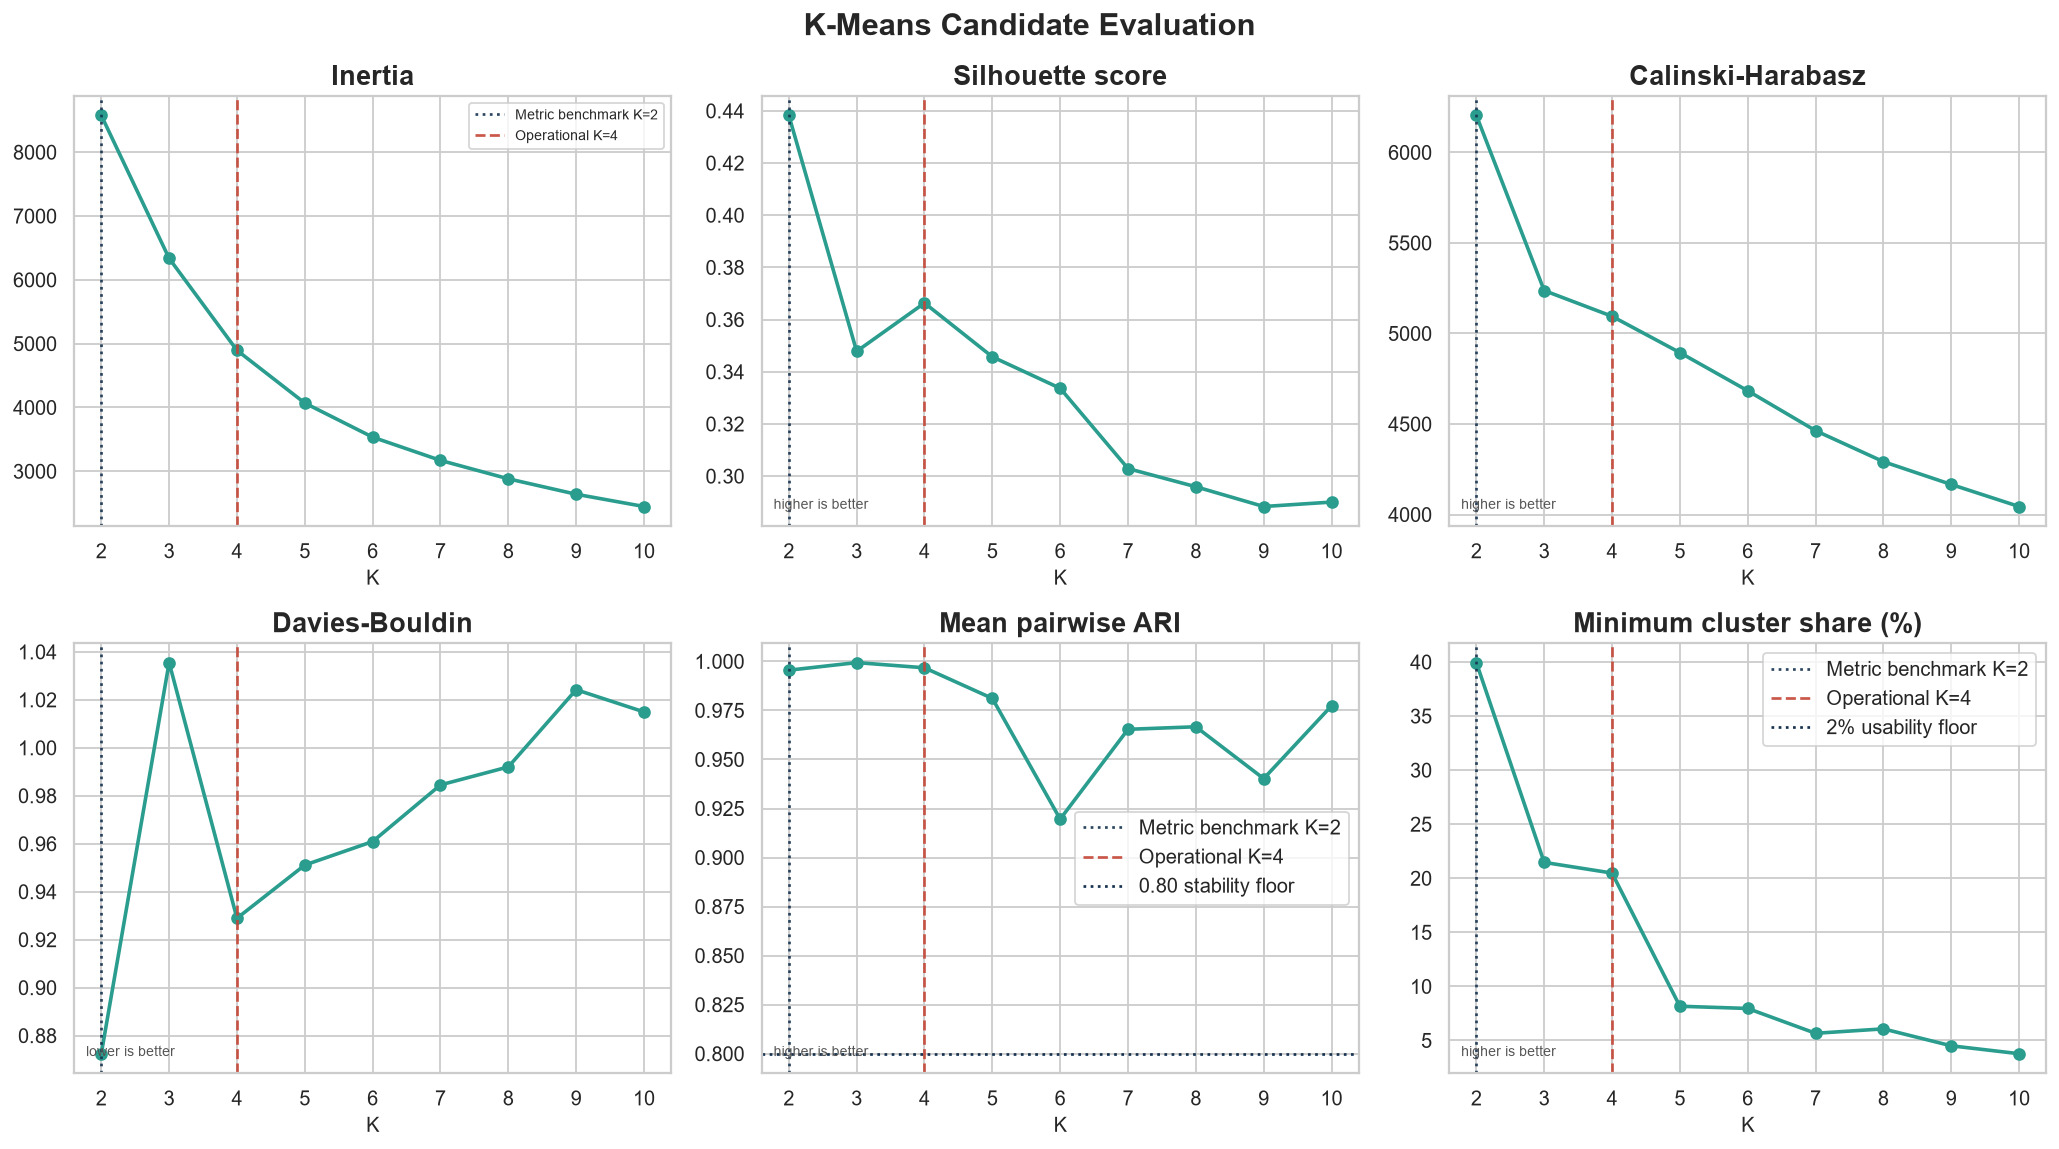

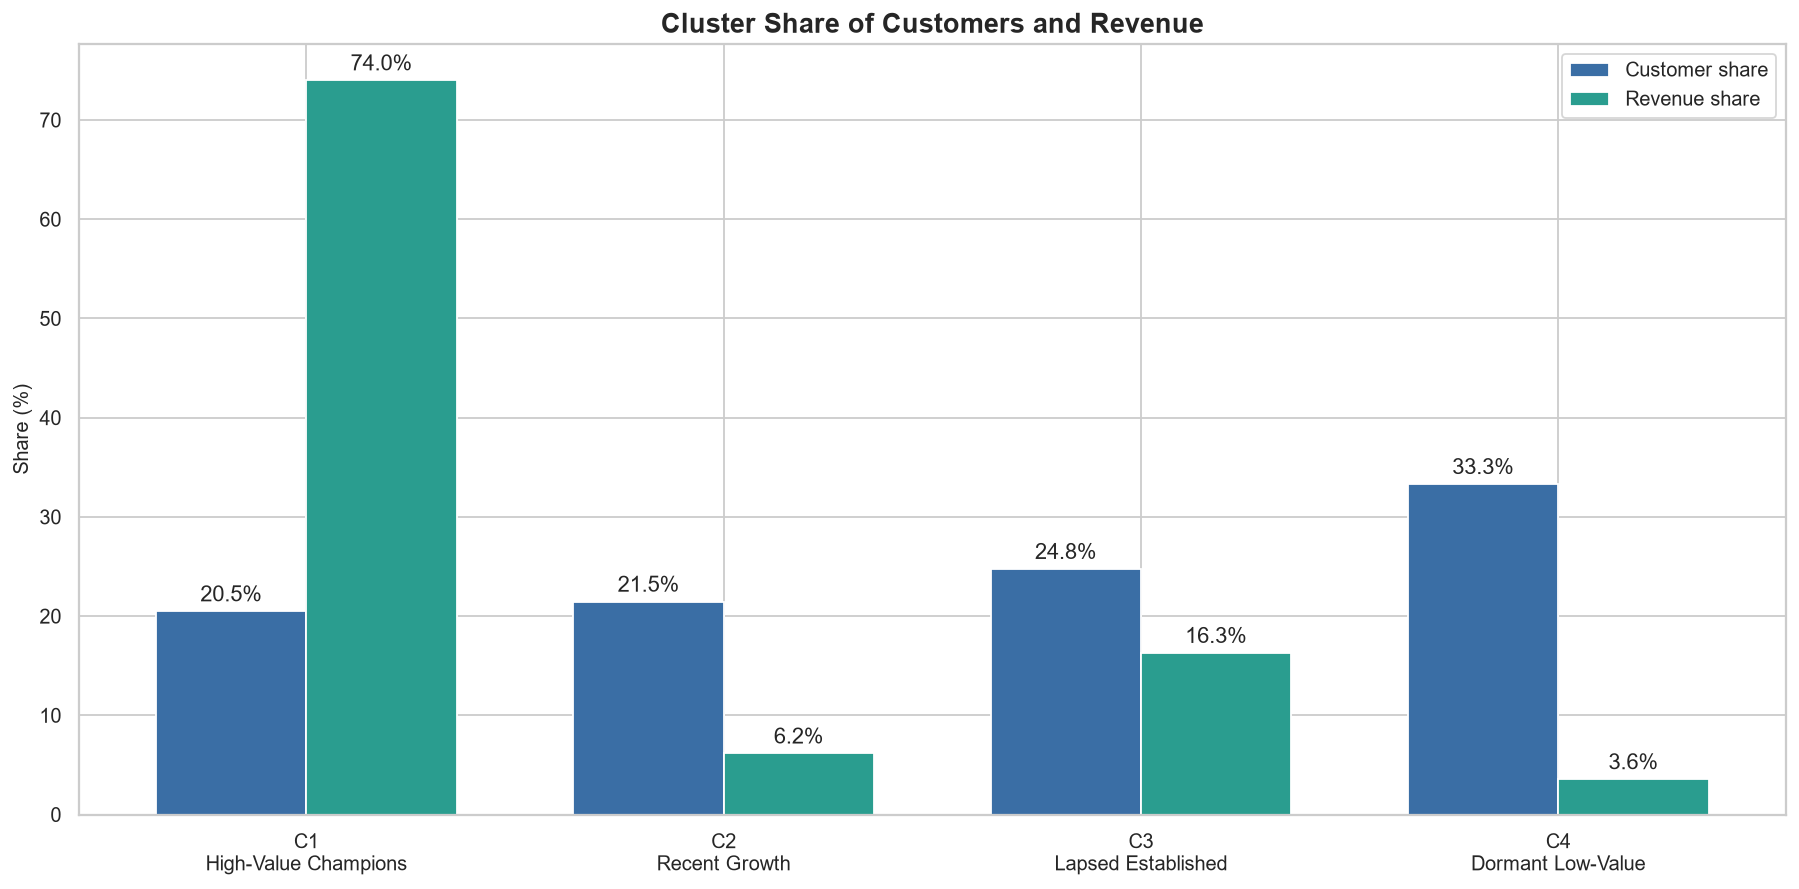

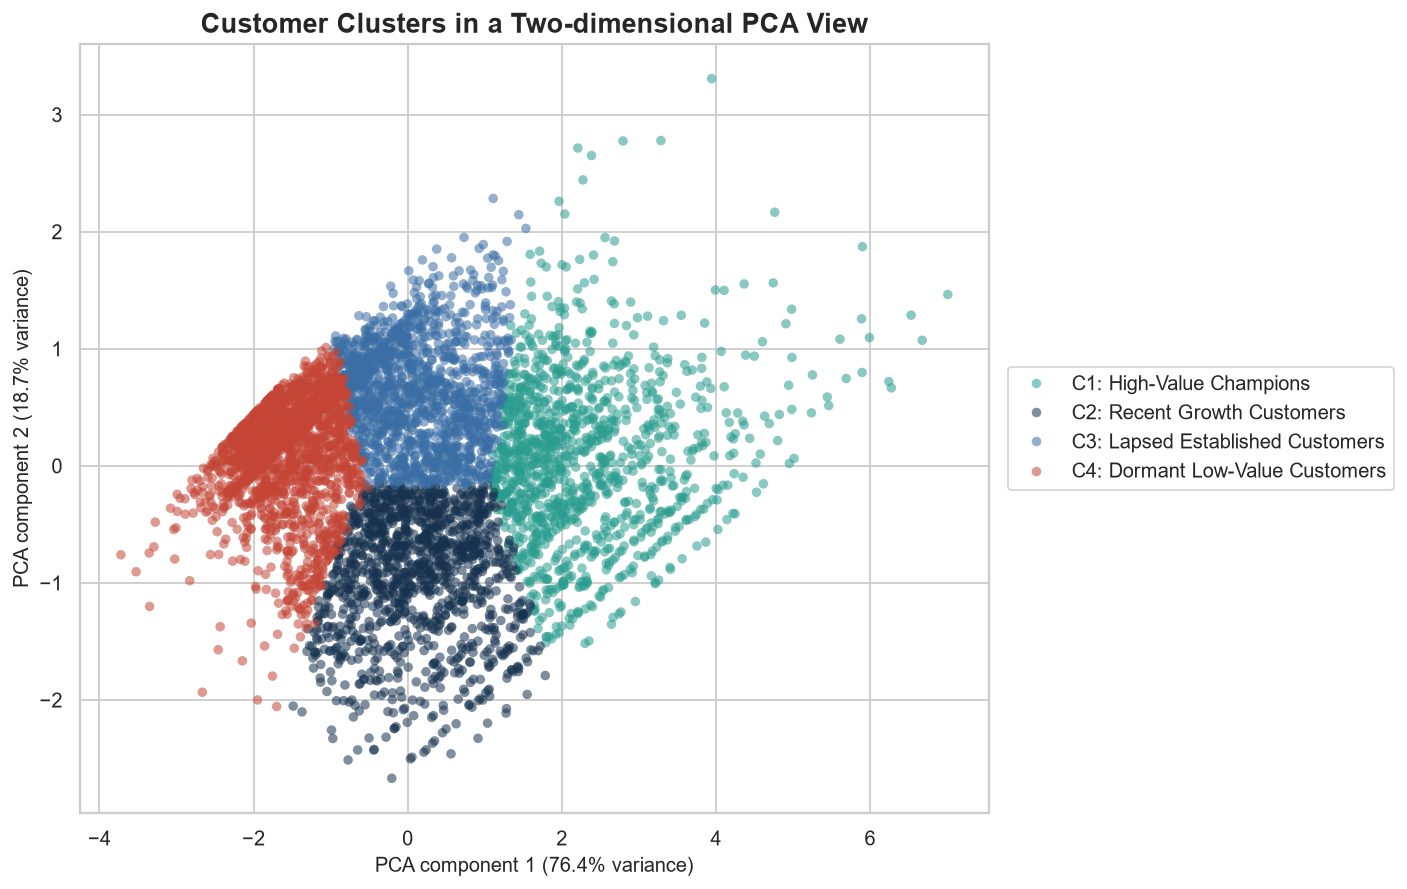

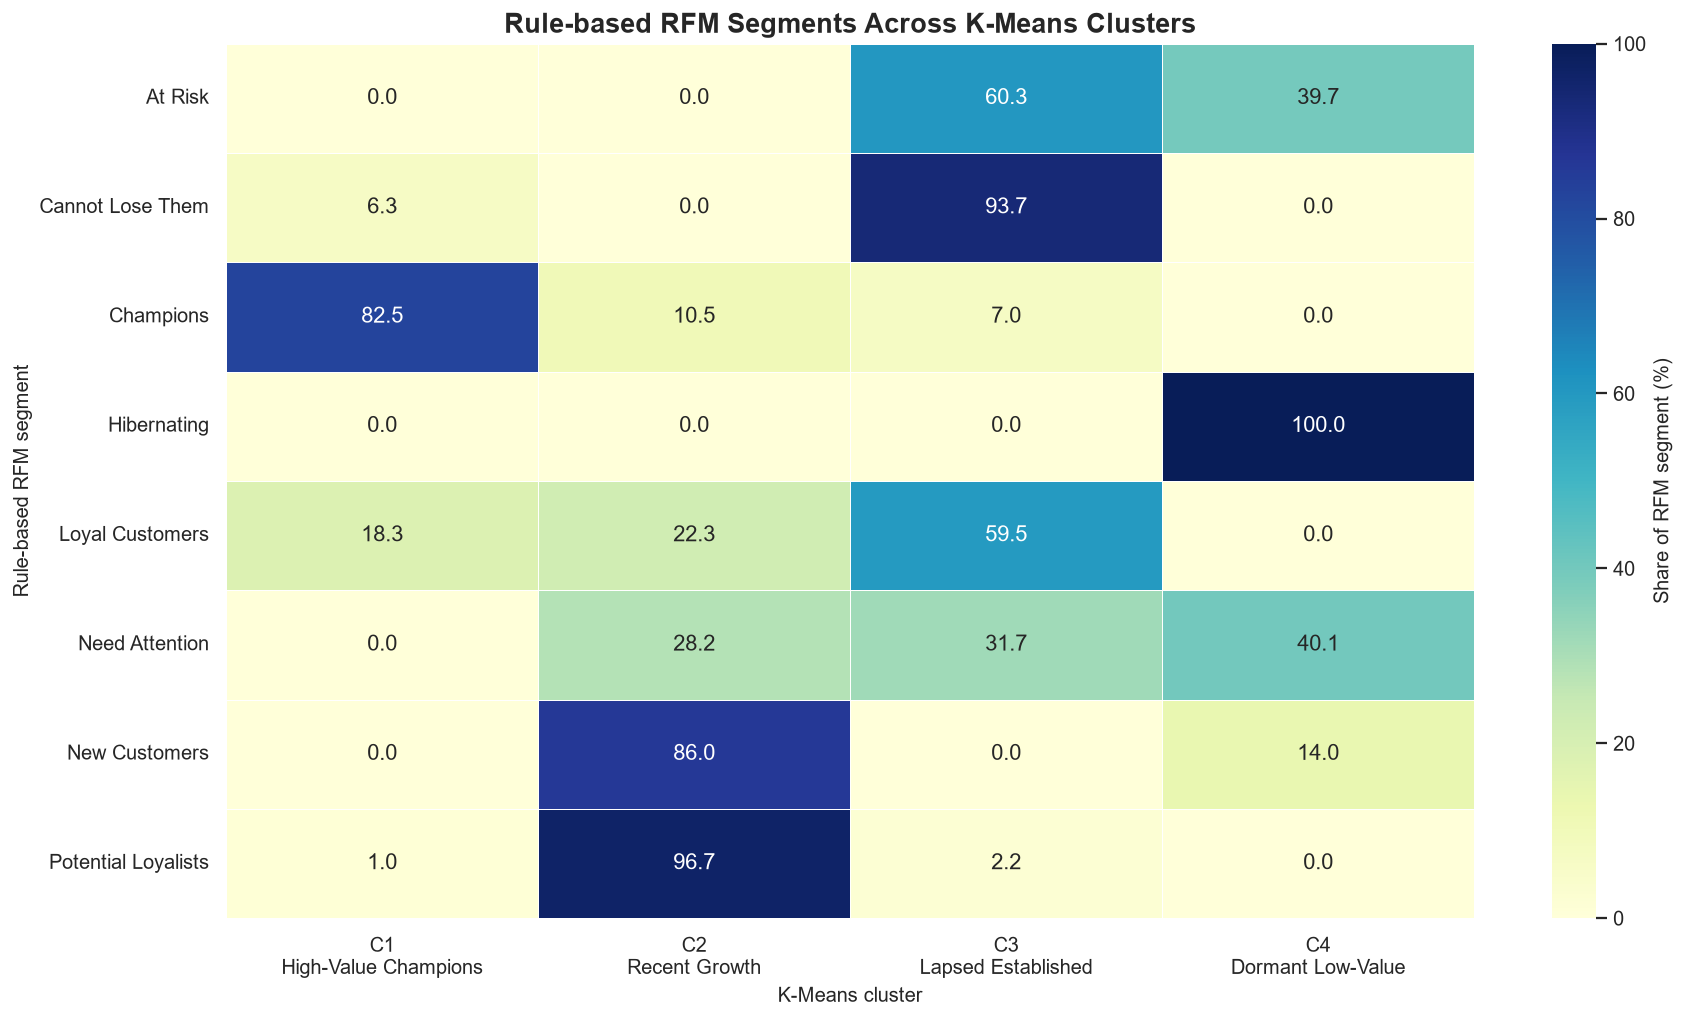

In [5]:
for chart in [
    "images/clustering/01_k_evaluation.png",
    "images/clustering/02_cluster_size_and_revenue.png",
    "images/clustering/03_pca_cluster_projection.png",
    "images/clustering/04_rfm_cluster_comparison.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart), width=900))

## Business Insights

- High-Value Champions are 20.48% of customers and contribute 74.00% of identified-customer revenue, supporting protective service and relevant loyalty treatment.
- Recent Growth Customers are comparatively recent but lower in frequency and value, supporting measured next-purchase nurturing.
- Lapsed Established Customers have meaningful prior frequency and value but much higher recency, making profile-based reactivation more proportionate than broad discounting.
- Dormant Low-Value Customers are the largest group but contribute 3.56% of revenue; low-cost re-engagement tests fit that profile.
- The five-seed mean ARI for K=4 is about 0.997, indicating highly stable assignments under the tested initialisations.

## Assumptions

- Recency, frequency, and monetary value are valid descriptive inputs for customer grouping.
- `log1p` and standardisation reduce scale/skew dominance without changing original-unit profile reporting.
- The 2% minimum-share and 0.80 stability floors define operational usability.

## Limitations

- K-Means imposes spherical partitions in transformed feature space.
- PCA is only a visual projection and is not used to fit or select clusters.
- Clusters are **descriptive, not causal or predictive**; labels do not establish campaign response, churn, or future value.
- The historical observation window and wholesale-like customers influence RFM measures.

## Next Steps

- Validate cluster actions through controlled experiments and future-period outcomes.
- Monitor cluster-size and profile drift after each refresh.
- Retain both K=2 benchmark metrics and K=4 operational evidence in governance reviews.